In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from copy import deepcopy

import sys

sys.path.append('../src')

from Config.config import PATHS

import warnings
warnings.filterwarnings("ignore")

### Test FRA agents

In [2]:
from Classes.bar import Bar
from Classes.focal_regions import FocalRegion
from Utils.interaction import Episode
from Classes.cognitive_model_agents import PayoffICSMM1

In [9]:
free_parameters = {
    'inverse_temperature': 8,
    'learning_rate': 0.2,
    'len_history': 2,
    'max_regions':3,
    'delta': 0.2,
}
fixed_parameters = {
    'num_agents': 4,
    'threshold': 1/4,
}
n = 1

In [10]:
# Create the environment
bar = Bar(
    num_agents=fixed_parameters['num_agents'],
    threshold=fixed_parameters['threshold']
)
# Create the agents
agents = [
    PayoffICSMM1(
        free_parameters, 
        fixed_parameters, 
        n
    ) for n in range(fixed_parameters['num_agents'])
]

<Axes: >

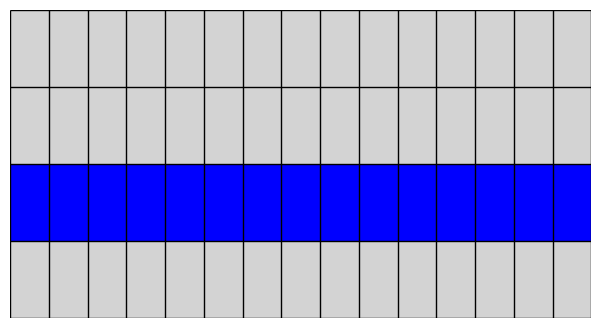

In [18]:
for agent in agents:
    for fra in agent.sfr.focal_regions:
        fra.debug = False

    agent.sfr.debug = False

# Create the episode
episode = Episode(
    model='FRA',
    agents=agents,
    environment=bar,
    num_rounds=15
)

episode.run()
bar.render()

# Test simulations

In [19]:
from Utils.interaction import Performer

In [ ]:
free_parameters = {
    'inverse_temperature': 8,
    'learning_rate': 0.2,
    'len_history': 2,
    'max_regions':3,
    'delta': 0.2,
}

simulation_parameters = {
    'num_rounds': 50,
    'num_episodes': 100,
    'verbose': False
}

In [24]:
list_fixed_parameters = [
    (2, 0.5),
    (3, 1/3), 
    (3, 2/3),
    (4, 1/4), 
    (4, 0.5), 
    (4, 3/4),
]

from tqdm.auto import tqdm

df_list = []
for max_regions in tqdm([1, 3, 6, 12], desc='Number of regions'):
    free_parameters['max_regions'] = max_regions
    for num_agents, threshold in (pbar := tqdm(list_fixed_parameters, leave=False)):
        fixed_parameters = {
            'num_agents': num_agents,
            'threshold': threshold,
        }
        pbar.set_description(f"n={num_agents}, thr={threshold:.4g}")
        model_class = PayoffICSMM1
        df2 = Performer.sim(
            agent_class=model_class,
            fixed_parameters=fixed_parameters,
            free_parameters=free_parameters,
            simulation_parameters=simulation_parameters,
        )
        df2['model'] = str(max_regions)
        df_list.append(df2)

df2 = pd.concat(df_list, ignore_index=True)
df2['bounded_score'] = df2['score'] / df2['threshold']

Number of regions:   0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

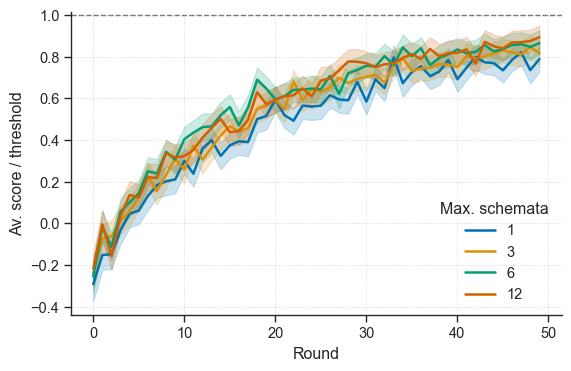

In [26]:
sns.set_theme(style='ticks', context='paper', font_scale=1.2)

fig, ax = plt.subplots(figsize=(5.6, 3.6), layout='constrained')

hue_order = [str(n) for n in [1, 3, 6, 12]]

sns.lineplot(
    data=df2,
    x='round',
    y='bounded_score',
    hue='model',
    hue_order=hue_order,
    palette='colorblind',
    errorbar=('ci', 95),
    linewidth=1.8,
    ax=ax,
)

ax.axhline(
    1, color='0.4', linestyle='--', linewidth=1, zorder=0,
)
ax.set_xlabel('Round')
ax.set_ylabel('Av. score / threshold')
ax.grid(True, linestyle=':', linewidth=0.6, color='0.75', alpha=0.7)

legend = ax.get_legend()
if legend is not None:
    legend.set_title('Max. schemata')
    legend.set_frame_on(False)

sns.despine(ax=ax)

file = Path('..', 'images', 'exploratory', 'fra_max_regions_score.png')
file.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(file, dpi=300, bbox_inches='tight')

In [ ]:
from Utils.interaction import Performer
from Utils.utils import GetMeasurements
from Classes.cognitive_model_agents import FRAplus

**FRAplus**

In [ ]:
fixed_parameters = {
	"num_agents":4,
	"threshold":0.3,
}
free_parameters = {
    'inverse_temperature': 8, 
    'learning_rate': 0.2, 
    'bias': 0.75, 
    'len_history': 2, 
    'delta': 0.4,
    'max_regions': 5,
}
simulation_parameters = {
	'num_rounds': 100,
    'num_episodes': 100,
	'verbose':False
}

In [ ]:
df = Performer.sim(
    agent_class=FocalRegionAgent,
    fixed_parameters=fixed_parameters,
    free_parameters=free_parameters,
    simulation_parameters=simulation_parameters
)
df['bounded_score'] = df['score'] / df['threshold']
gm = GetMeasurements(
    data=df, measures=['bounded_efficiency', 'gini_index']
)
data = gm.get_measurements()
ax = sns.scatterplot(
    x='gini_index', y='bounded_efficiency',
    data=data
)
# ax.set_xlim([-0.05, 0.6])
# ax.set_ylim([-0.05, .55])

In [ ]:
sns.lineplot(
    x='round', y='bounded_score',
    data=df
)

# Test parameter fit

In [ ]:
from Classes.cognitive_model_agents import FRAplus
from Classes.parameter_recovery import ParameterFit

In [ ]:
# my_models = [FocalRegionAgent]
my_models = [FRAplus]

best_fit_file_2P = PATHS['parameter_fit_results'] / 'best_fit_2P_3.json'

#Load 2P data
file = PATHS['human_data'] / '2-player-UR.csv'
print(f'Loading data from {file}...')
data = pd.read_csv(file)
data.head(2)

In [ ]:
hyperparameters = {
    'n_iter': 128,
    'init_points': 64,
}

ParameterFit.run(
    data=data,
    model_list=my_models,
    best_fit_path=best_fit_file_2P,
    optimizer_type='bayesian',
    hyperparameters=hyperparameters,
    new_file=False
)

In [ ]:
ParameterFit.run(
    data=data,
    model_list=my_models,
    best_fit_path=best_fit_file_2P,
    optimizer_type='scipy',
    hyperparameters={},
    new_file=False
)

{'inverse_temperature': np.float64(5.939793200426039), 'bias': np.float64(0.7908615558239465), 'learning_rate': np.float64(0.18051110357718222), 'len_history': np.float64(2.4724091615619512), 'c': np.float64(1.0), 'delta': np.float64(0.1)}
Deviance: -2181.1293794903972
AIC: 4374.2587589807945

In [ ]:
from Classes.parameter_recovery import GetDeviance

free_parameters = {
    'inverse_temperature': 6, 
    'bias': 0.79, 
    'learning_rate': 0.18, 
    'len_history': 2, 
    'c': 0.1, 
    'delta': 0.1
}
g_dev = GetDeviance(
    model=FRAplus,
    free_parameters=free_parameters,
    data=data
)

g_dev.get_deviance_from_data(free_parameters)

---